How numerous are numbers in Latin poetry? It is one of those questions that a reader may have a vague sense of through the act of reading, but which would be difficult to quantify through reading alone. Surely you could read a Latin poem keeping a numeric scorecard as work through the text. And, in fact, that is exactly what we will do, or more precisely what we will task the computer with doing, since this is the kind of the "reading" at which the computer excels. So, for this experiment, let's build a number counter that reads the works of Virgil—the *Eclogues*, the *Georgics*, the *Aeneid*—and keeps a tally of numbers that are encountered in each texts. We will then use the results to offer a provisional answer to the question—which of Virgil's works is the most "numerical"?

<span class='.preview-image' style="display: none;"><img src='preview.png'></img></span>

**Run this notebook in the browser using Binder here [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/diyclassics/epblog/notebooks?labpath=notebooks%2Fvirgilian-numbers.ipynb)**

Is this a good research question? It is surely not a completely uninteresting one. But what I want you to keep in mind as we develop this exercise—it is not so much that we are interested in "numericalness" as much as we are interested in description in general. How do we go about describing the texts we read? And how can computers help with this?

Sure we have some familiar ways of describing texts, e.g. genre. The *Aeneid* is an epic poem. The *Eclogues* is a collection of bucolic poetry. The *Georgics* are... well, sometimes I'm not sure I really know what the *Georgics* are, but they are certainly some sort of didactic poem. But once we are able to discern the formal features of texts, identify them, collect and count them, we can describe any number of literary phenomena. I could have just as easily chosen "animalness" in Virgil or "colorfulness" in Virgil. (We will in fact look at color in a later post.) Here we start with numbers and we do so for a specific reason. Numbers—for the most part, and for our purposes in this experiment, entirely so—are indeclinable. That means, at least at first, that we can restrict our attention to the wordform as it appears in the text, i.e. the token, and not to its dictionary definition, i.e. the lemma. We will though by the end of the post move on to working with lemmas.

Our plan then in this experiment based on another chapter—see another chapter preview here—from the upcoming book *Exploratory Philology* is to generate a determine a kind of Virgilian "numericalness."

So, what do we need to do to determine this "numericalness"? Before we write out any Python code, we turn first to pseudocode, i.e. a plain language description of the steps we will take to solve our problem. As I see the problem given above, we need to do the following...

**Pseudocode for counting numbers in Virgil**

1. Load our library of Latin texts, keeping only those by Virgil
2. Create a list of words that we will consider numbers
3. For each text by Virgil...
    a. Read the text into memory
    b. Count the words in the text that are also in the our number list
    c. Store the count of numbers in the text
4. Create a table of number counts

As you will see below, we will qualify how we present this table of counts, spec. normalizing the counts by text length. But for now we our pseudocode provides an excellent starting point for proceeding with our Describe experiment.

In [1]:
# Preliminary imports

from natsort import natsorted
from pprint import pprint
from time import sleep

As always, let's set up our corpus reader and pull out the texts we want to describe.

In [2]:
# PC 1: Load our library of Latin texts, keeping only those by Virgil

from cltkreaders.lat import LatinTesseraeCorpusReader

CR = LatinTesseraeCorpusReader()

eclogues = natsorted(CR.fileids(match='eclogues'))
georgics = natsorted(CR.fileids(match='georgics'))
aeneid = natsorted(CR.fileids(match='aeneid'))

In order to find items in our texts, we will test for inclusion using the `in` operator. For example, we can check whether the number 'seven', i.e. *septem*, is in the text of the *Eclogues* by using the following code...

In [3]:
eclogues_words = [word for word in list(CR.words(eclogues, plaintext=True))]
pprint('septem' in eclogues_words)

True


It is! And since this word in both indeclinable and unambiguous with respect to lemma (i.e. there is no other Latin word that has an oblique form *septem*), we can be confident that we have found what we are looking for. Same for *octo*...

In [4]:
print('octo' in eclogues_words)

False


The word *octo* does not appear in the *Eclogues*. Again, we make this determination by checking for inclusion with the `in` operator. In order to get to where we want to go with this experiment, all we need to do is scale up our process—check more words against more texts, keeping track of what we find along the way. Let's continue with the *Eclogues* and, instead of checking individual numbers, we will loop over a list of numbers, checking each one against the text. As noted above, we will skip the "declinable" numbers for now and limit ourselves to the numbers four through ten, i.e. our "indeclinables."

First, we make a list of numbers...

In [5]:
# PC 2: Create a list of words that we will consider numbers

numbers = ['quattuor', 'quinque', 'sex', 'septem', 'octo', 'nouem', 'decem']

...and then loop over this list. For now, we will just print `True` when the number is encountered and `False` when it is not...

In [6]:
for number in numbers:
    print('--------------------')
    print(f"Checking '{number}' in eclogues_words...")
    if number in eclogues_words:
        print(f'Found {number}!')
    else:
        print(f'Not found.')
    print('--------------------')
    sleep(1)

--------------------
Checking 'quattuor' in eclogues_words...
Found quattuor!
--------------------
--------------------
Checking 'quinque' in eclogues_words...
Not found.
--------------------
--------------------
Checking 'sex' in eclogues_words...
Not found.
--------------------
--------------------
Checking 'septem' in eclogues_words...
Found septem!
--------------------
--------------------
Checking 'octo' in eclogues_words...
Not found.
--------------------
--------------------
Checking 'nouem' in eclogues_words...
Not found.
--------------------
--------------------
Checking 'decem' in eclogues_words...
Found decem!
--------------------


Surely, though it would be better to keep track of, not only whether a word is seen or not, but also of how many times we see it. We can do this easily enough by using a data structure specifically designed for this task, namely `Counter`. `Counter` is a dictionary-like structure in which keys, i.e. here the number words, are mapped to values, i.e. the number of times the key is seen. We just need to increment the count, i.e. add one to the existing value, every time a new instance of the number word is seen. We will once again use the `in` operator to check for inclusion, but note that this time we reverse the test—instead of checking whether the number word is in the text, we check whether each word in the text is in the list of number words.

In [7]:
# PC 3a & b: 
#    - Count the words in the text that are also in the our number list
#    - Store the count of numbers in the text

from collections import Counter

C = Counter()

for word in eclogues_words:
    if word in numbers:
        C[word] += 1

print(C)

Counter({'decem': 2, 'septem': 1, 'quattuor': 1})


That is not a lot of number words. Again, think back to the beginning of this post—as a reader of the *Eclogues* you may intuit that numbers just do not come up often. But could you have read the ten poems start to finish and announced that you had seen the number *septem* only once? Probably not.

One of the most empowering things about computational approaches to philological problems is the flexibility that comes from simple refactoring. With a change of very little, only a line or two of code, we can switch easily from the "numericalness" of the *Eclogues* to that of the *Georgics*...

In [8]:
georgics_words = list(CR.words(georgics, plaintext=True))

And let's just get the *Aeneid* words out of the way now too...

In [9]:
aeneid_words = list(CR.words(aeneid, plaintext=True))

`Counter` works pretty fast and—in the interest of showing the many different ways to approach a philological problem—let's arrive at our number counts in a slightly different way this time. Let's build a counter for each poem with **all** of the words and then only keep the counts of interest, i.e. the number words. We do this not with a list comprehension, like e.g. we have seen when working with our file list, but rather a dictionary comprehension.

It works like so: we loop over the numbers list and make each number a key in the dictionary while assigning that key the value from the complete word count. A nice trick and an efficient one—it takes no more time to count everything and select from what we have than to loop over everything and add what we want and it is likely faster. Loops have their place in coding and we will use them often. But we should recognize too that there are often more efficient ways to approach problems. We will see this over and over again in exploratory philological work.

In [10]:
eclogues_C = Counter(eclogues_words)
georgics_C = Counter(georgics_words)
aeneid_C = Counter(aeneid_words)

eclogues_nums_C = {k: eclogues_C[k] for k in numbers}
georgics_nums_C = {k: georgics_C[k] for k in numbers}
aeneid_nums_C = {k: aeneid_C[k] for k in numbers}

# Print an example
print(georgics_nums_C)

{'quattuor': 6, 'quinque': 0, 'sex': 0, 'septem': 3, 'octo': 1, 'nouem': 0, 'decem': 1}


We know have three Counters with "numericalness" data from each of Virgil's works. Let's present them in a tabular format so that we can compare them.

In [11]:
# PC 4: Create a table of number counts

import pandas as pd

df = pd.DataFrame([eclogues_nums_C, georgics_nums_C, aeneid_nums_C], index=['Eclogues', 'Georgics', 'Aeneid'])
df

,quattuor,quinque,sex,septem,octo,nouem,decem
Eclogues,1,0,0,1,0,0,2
Georgics,6,0,0,3,1,0,1
Aeneid,7,1,4,12,0,0,2


The *Aeneid* has more numbers than the other two works—at least, more of the numbers 4 through 10. But this twelve-book epic poem is also much longer than the other works. Is this a fair comparison? Not at all. So let's take the added step of normalizing the existing counts. We do this by dividing each count by the number of words in the corresponding text. To make things more readable—these are afterall very low wordcounts—we multiply the result by 1000 and to make things even more readable we can round this number to two decimal places. What we have then is a count per 1000 words which we can use as a basis for comparison. 

First, we need whole-work word counts. This is all straightforward enough, though putting it all together compactly verges towards an advance topic. Here is how you could approach it—don't worry if all of the details are not clear yet. We will explore Pandas in greater depth in subsequent posts.

In [12]:
eclogues_words_total = len(eclogues_words)
georgics_words_total = len(georgics_words)
aeneid_words_total = len(aeneid_words)

# Print an example
print(f'There are {eclogues_words_total} words in the Eclogues.')

There are 7114 words in the Eclogues.


In [13]:
counts = [eclogues_words_total, georgics_words_total, aeneid_words_total]

df_norm = df.div(counts, axis='rows').mul(1000).round(2)
df_norm

,quattuor,quinque,sex,septem,octo,nouem,decem
Eclogues,0.14,0.00,0.00,0.14,0.00,0.0,0.28
Georgics,0.36,0.00,0.00,0.18,0.06,0.0,0.06
Aeneid,0.09,0.01,0.05,0.15,0.00,0.0,0.03


But what we really want is a total of our words of interest over the total word count...

In [14]:
df_nums = df.sum(axis=1)
df_nums

Eclogues     4
Georgics    11
Aeneid      26
dtype: int64

In [15]:
df_nums.div(counts, axis='rows').mul(1000).round(3)

Eclogues    0.562
Georgics    0.654
Aeneid      0.328
dtype: float64

Just to confirm that we understand how Pandas arrives at this number for the *Eclogues*...

In [16]:
print(f'Step 1: 4 number words / {eclogues_words_total} total words = {4/7129}')
print(f'Step 2: ( 4 number words / {eclogues_words_total} total words ) * 1000 = {(4/7129) * 1000}')
print(f'Step 3: "        "        "    rounded to the third decimal place = {round((4/7129) * 1000, 3)}')

Step 1: 4 number words / 7114 total words = 0.0005610885117127227
Step 2: ( 4 number words / 7114 total words ) * 1000 = 0.5610885117127227
Step 3: "        "        "    rounded to the third decimal place = 0.561


So while the *Aeneid* has more number words in absolute terms that the other two works, in relative terms it has fewer. And the *Georgics* edges out the *Eclogues*—at least as we defined the problem—i.e. as a count of the indeclinable numbers *quattuor* through *decem*. Let's see what we can do now with lemmas and not just tokens.

We will use a data structure available to us in the Tesserae CorpusReader called `tokenized_sents` which generates one sentence at a time in the format of a list of length-three tuples of the form (*token*, *lemma*, *POS tag*). Here is an example from the beginning of the *Eclogues*...

In [17]:
eclogues_tokenized_sents = CR.tokenized_sents(eclogues)

pprint(next(eclogues_tokenized_sents)[:5])

[('Tityre', 'Tityrus', 'PROPN'),
 (',', ',', 'PUNCT'),
 ('tu', 'tu', 'PRON'),
 ('patulae', 'patulus', 'NOUN'),
 ('recubans', 'recubo', 'VERB')]


We can now increase our list of numbers now to include the 'declinables', i.e. the Latin words for the numbers one through three. And we can do so using lemmas, since we now have access to that information through the `tokenized_sents`. Having increased the number list, we can iterate once again over our texts to get updated counts.

In [18]:
numbers = ['unus', 'duo', 'tres', 'quattuor', 'quinque', 'sex', 'septem', 'octo', 'nouem', 'decem']

eclogues_tokenized_sents = CR.tokenized_sents(eclogues)

eclogues_lemmas = []

for sent in eclogues_tokenized_sents:
    for word, lemma, pos in sent:
        eclogues_lemmas.append(lemma)

eclogues_C = Counter(eclogues_lemmas)

eclogues_nums_C = {k: eclogues_C[k] for k in numbers}        

# Print an example
print(eclogues_nums_C)             

{'unus': 5, 'duo': 6, 'tres': 2, 'quattuor': 0, 'quinque': 0, 'sex': 0, 'septem': 1, 'octo': 0, 'nouem': 0, 'decem': 2}


In [19]:
georgics_tokenized_sents = CR.tokenized_sents(georgics)

georgics_lemmas = []

for sent in georgics_tokenized_sents:
    for word, lemma, pos in sent:
        georgics_lemmas.append(lemma)

georgics_C = Counter(georgics_lemmas)

georgics_nums_C = {k: georgics_C[k] for k in numbers}

# Print an example
print(georgics_nums_C)        

{'unus': 11, 'duo': 6, 'tres': 2, 'quattuor': 2, 'quinque': 1, 'sex': 0, 'septem': 3, 'octo': 1, 'nouem': 0, 'decem': 1}


In [20]:
aeneid_tokenized_sents = CR.tokenized_sents(aeneid)

aeneid_lemmas = []

for sent in aeneid_tokenized_sents:
    for word, lemma, pos in sent:
        aeneid_lemmas.append(lemma)

aeneid_C = Counter(aeneid_lemmas)

aeneid_nums_C = {k: aeneid_C[k] for k in numbers}

# Print an example
print(aeneid_nums_C)        

{'unus': 115, 'duo': 22, 'tres': 15, 'quattuor': 2, 'quinque': 3, 'sex': 4, 'septem': 12, 'octo': 0, 'nouem': 0, 'decem': 2}


We combine these again into a dataframe of raw counts...

In [21]:
lemma_df = pd.DataFrame([eclogues_nums_C, georgics_nums_C, aeneid_nums_C], index=['Eclogues', 'Georgics', 'Aeneid'])
lemma_df_nums = lemma_df.sum(axis=1)
lemma_df_nums

Eclogues     16
Georgics     27
Aeneid      175
dtype: int64

...and again normalize by total number of words in each text per 1000 words.

In [22]:
lemma_df_nums_norm = lemma_df_nums.div(counts, axis='rows').mul(1000).round(2)
lemma_df_nums_norm

Eclogues    2.25
Georgics    1.60
Aeneid      2.21
dtype: float64

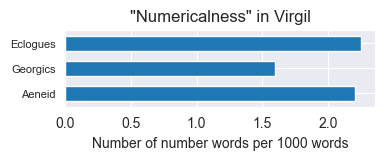

In [23]:
# A quick visualization...

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

plt.figure(figsize=(4, 1))
plt.rcParams['ytick.labelsize'] = 8

ax = lemma_df_nums_norm.plot(kind='barh', width=0.6)
ax.invert_yaxis()
ax.set(xlabel='Number of number words per 1000 words', title='"Numericalness" in Virgil');

With our increased wordlist—lemma list really—we see a shift in the results. The high number of *unus* instances shifts the *Eclogues* into the lead as the most numerical of the three works with the *Georgics* slipping to third. But these are only results, not conclusions. So many questions remain...

- Does this match our prior expectation of Virgilian "numericalness" from our reading experience?
- Is the count of *unus* correct, i.e. how accurate is our lemmatizer? (see *Error analysis* below)
- What about numbers higher than 10? etc.

But while questions remain, it is also true that we have these questions because we were able with a reasonable amount of effort to engage in some exploratory textual data analysis with our texts. To apporach these questions with pen-and-paper would take hours; with Python, it takes *minutes*. This is a considerable extension of our philological toolkit.

Where to turn next? In *Exploratory Philology*, a great deal of attention is given to small acts of refactoring that open up wide avenues of potential further inquiry. A few examples based on this experiment...

- ***Change author***: What if we wanted to compare the "numericalness" of Virgil's works to those of another author? How would we do this? What other authors might we compare to Virgil? Perhaps we could try the experiment again with Ovid? or Lucan?

- ***Change concept***: What if, instead of "numericalness, we want to capture a different concept? What if we wanted to compare the "animalness" of Virgil's works? How might we approach this problem? (Hint: we could start with a single animal word, e.g. *equus*, and then expand to an increasingly longer list of animal words.) How are animals (or other concepts) different from numbers? Or, stated differently, could you ever compose a complete list of animal words?

- ***Compare against existing arguments***: @bramble_lucan_1983 (following @andre_etude_1949) writes that Lucan's use of color vocabulary is "less rich than that of mainstream epic" and that it is a "predominantly monchrome epic." Does this bear itself out under further scrutiny? (It may be further helpful to consult Bramble's loose statistical account of this phenomenon, e.g. does *virens* appear only once in Lucan (and specifically at 9.523? is it the only "green" word?) Or when we see that Bramble writes—"From a total of 34 terms, white, grey and black are the dominant tones, accounting for in terms with 64 occurrences."—how can operationalize this loose definition of color terms into something that can be quantified using the methods above?

- ***Error analysis***: Our results are only as good as our data and the tools/methods applied to our data. So, it is important that we have a sense of the accuracy of what has been output to the tables above. E.g. the [lemmatizer](https://huggingface.co/latincy/la_core_web_lg) used in the `tokenized_sents` method above has a reported accuracy of 94.6%—good, but obviously not perfect. One place where we should already have some pause—for our word counts in the Aeneid, we have *sex* at 6 instances and in our lemmas counts we have 8 instances. Something is off—as a next step, it would be a good idea to open up the Aeneid texts and search and/or read through the file to see what may be happening. It is good to do this kind of error analysis periodically so that we are aware of what is working well and what isn't in our philological explorations.

### References

::: {#refs}
:::